# 22. Differential Growth: The Restless Line

Part V has given us agents that fly (chapter 19), freeze on contact (20), and follow each other's trails (21). Today the strangest crowd of all: agents chained into a single closed line, each negotiating every move with two permanent neighbors, while the chain itself grows. The result is a line that cannot sit still and cannot cross itself, so it does the only thing left: it ruffles.

## Today's destination

One line. The showpiece below contains a single closed loop of ink, no branches, no crossings, drawn by no hand: it began as a circle of forty points and grew, node by node, edge by edge, into a labyrinth packed against a circular wall, the way a kale leaf packs its hem or a brain packs its cortex. By the end of today you will grow these yourself, steer them between lettuce and coral with two dials, and know why the buckling is not a choice but a mathematical inevitability.

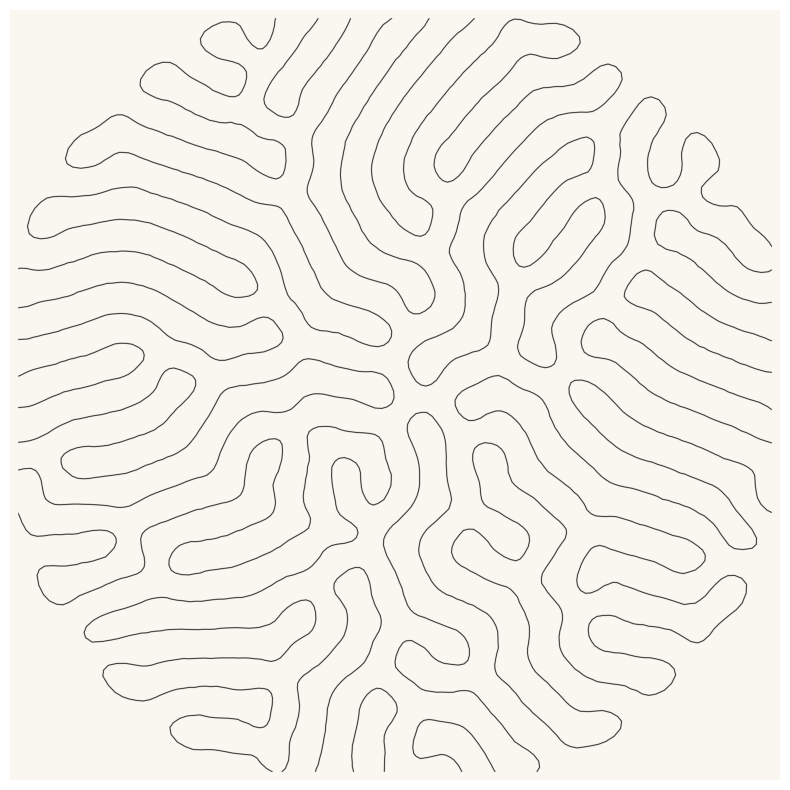

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch22_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: jewelry, plotters, and the hem of the kale leaf

In the studio economy of generative art, differential growth is the technique that most visibly *left the screen*. **Nervous System**, the studio Jessica Rosenkrantz and Jesse Louis-Rosenberg founded in 2007, has been turning growth simulations into physical objects for over a decade: their *Hyphae* lamps (2011) grew like leaf veins, and *Floraform*, begun in 2014, simulates a differentially growing elastic *surface*, inspired by blooming flowers and the cockscomb flower's ruffled crest, then 3D-prints the results as jewelry and sculpture. What we build today is that idea's planar cousin and the creative-coding community's standard form of it: not a growing surface but a growing *line* in the plane, the "differential line" that the Norwegian artist **Anders Hoff**, writing as *inconvergent*, documented in an influential series of essays around 2015-16. Hoff's grown lines, drawn by pen plotters in unbroken strokes, did much to shape the whole plotter-era aesthetic; chapter 26 will put the machinery for that on your desk, and today's single-line artwork is, not coincidentally, the most plottable image this book produces.

The pattern itself is much older than either studio, because biology got there first. Look at the hem of a kale or lettuce leaf: it ripples. The physics is well studied (Eran Sharon and colleagues showed it in *Nature* in 2002 with nothing but torn plastic sheets): when an edge grows *faster than the interior it is attached to*, the extra length has nowhere to lie flat, so it buckles out into waves, and waves upon the waves. No genetic blueprint for the ruffle is needed, only a growth rate and elasticity. Coral frills, the crest of the cockscomb, the folded cortex of the brain you are reading this with (a leading mechanical model, published by Tallinen and colleagues in 2016, generates realistic cortical folds from differential growth alone): one mechanism, many bodies. And presiding over the whole chapter, back from chapter 7, stands **D'Arcy Thompson**, whose *On Growth and Form* (1917) insisted that biological shape is physics and mathematics at work. In his day that was an argument conducted in prose and measurement; today it compiles. We write the three rules, and the leaf appears.

## The mathematics: three rules and an inevitability

The organism is a **closed polyline** (geschlossener Polygonzug): an ordered array of node positions where node $i$ is chained to $i-1$ and $i+1$, and the last node loops back to the first. Three local rules act every step:

1. **Cohesion.** Each node is pulled toward the midpoint of its two chain neighbors: a spring along the chain, $F_{\text{coh}} = k_c \,(p_{i-1} + p_{i+1} - 2 p_i)$, read aloud: *where my neighbors' average is, minus where I am.* It keeps the chain taut and smooth. (It is chapter 19's cohesion rule with the flock shrunk to a family of two.)
2. **Repulsion.** Each node pushes away from *every* node that strays inside its personal radius, chain neighbors excepted; this is chapter 19's separation rule, unchanged. Repulsion is what makes the line refuse to cross itself: a stranger's approach is repelled before contact.
3. **Growth.** Wherever an edge stretches past a threshold, insert a new node at its midpoint (`np.insert` on the coordinate array). New material arrives *in* the line, not at its ends; a closed loop has no ends.

Why must this buckle? Count what each side of the bargain can offer. Growth multiplies: every insertion adds an edge that can itself stretch and split, so the perimeter can grow without bound (we will watch it grow exponentially, on chapter 9's logarithmic axis). But the line lives in a bounded patch of plane, and a plane can only host so much non-crossing curve per unit area: repulsion enforces a minimum lane spacing, so available room grows only with *area*. Perimeter that multiplies, room that does not: the surplus must fold, and fold again, at every scale. Buckling is not an aesthetic we chose; it is the only exit the arithmetic leaves open. That is the deep kinship with the kale leaf, whose hem also grows faster than the plane it is stitched to.

One engineering note before the code, stated once and honestly: we implement everything as flock-style NumPy position arrays (no classes; chapter 19 taught the idiom), and for the "who is near me" question we use chapter 15's `cKDTree`, rebuilt every five steps rather than every step. A five-step-old tree occasionally misses a brand-new neighbor for a few frames; at our step sizes nothing visible goes wrong, and the run is several times faster. Simulation is full of such documented small dishonesties; the craft is keeping them small and documented.

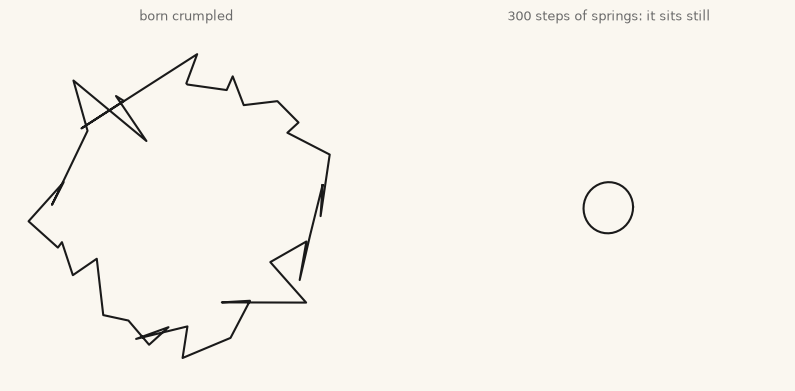

In [2]:
# the organism at rest: a circle of forty nodes, springs only
import sys
import numpy as np
from scipy.spatial import cKDTree

sys.path.append("..")                       # make the course package importable
from agap.helpers import PAPER, PALETTES, save_artwork

def make_loop(n_nodes=40, radius=16, wobble=3.0, seed=1):
    rng = np.random.default_rng(seed)
    angles = np.linspace(0, 2 * np.pi, n_nodes, endpoint=False)
    loop = np.column_stack([np.cos(angles), np.sin(angles)]) * radius
    return loop + rng.normal(0, wobble, loop.shape)   # crumple it a little

def cohesion_force(pos, k=0.22):
    return k * (np.roll(pos, 1, axis=0) + np.roll(pos, -1, axis=0) - 2 * pos)

crumpled = make_loop()
pos = crumpled.copy()
for _ in range(300):
    pos = pos + cohesion_force(pos)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), facecolor=PAPER)
for ax, loop, title in [(axes[0], crumpled, "born crumpled"),
                        (axes[1], pos, "300 steps of springs: it sits still")]:
    closed = np.vstack([loop, loop[:1]])
    ax.plot(closed[:, 0], closed[:, 1], color="#1A1A1A", lw=1.5)
    ax.set_xlim(-22, 22)
    ax.set_ylim(-22, 22)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

The negative control, and worth its cell: springs alone are an *anti*-generative force. They iron out the crumples, shrink the loop a little (each node forever chasing its neighbors' midpoint), and deliver a tidy ring that will now sit unchanged until the sun burns out. Every interesting thing in this chapter comes from the other two rules; the springs are there so that what grows stays a *line* instead of dissolving into a swarm.

## Rule two: strangers keep their distance

Repulsion needs to know who is near. The honest first version asks everyone about everyone: compute the full table of pairwise offsets with broadcasting (every node minus every node, an $n \times n \times 2$ array), find the pairs closer than the radius, and push them apart. At forty nodes that table has 1,600 entries and costs nothing; at four thousand it would have sixteen million, which is why the fast version follows.

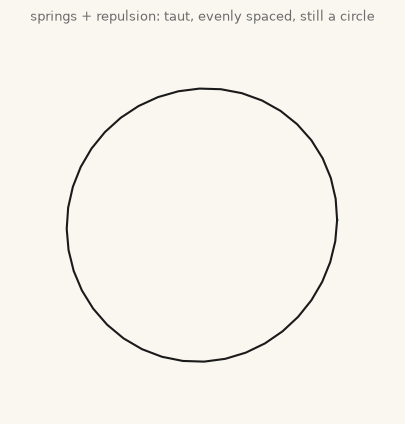

In [3]:
# repulsion, brute force: the full pairwise table (fine at small n)
def repulsion_force_slow(pos, radius=10.0, k=0.55):
    offsets = pos[:, None, :] - pos[None, :, :]      # every node minus every node
    distances = np.hypot(offsets[..., 0], offsets[..., 1]) + 1e-9
    n = len(pos)
    index_gap = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :])
    strangers = (distances < radius) & (index_gap > 2) & (index_gap < n - 2)
    falloff = np.where(strangers, 1 - distances / radius, 0.0)
    return k * (offsets / distances[..., None] * falloff[..., None]).sum(axis=1)

pos = crumpled.copy()
for _ in range(300):
    pos = pos + cohesion_force(pos) + repulsion_force_slow(pos)

fig, ax = plt.subplots(figsize=(5, 5), facecolor=PAPER)
closed = np.vstack([pos, pos[:1]])
ax.plot(closed[:, 0], closed[:, 1], color="#1A1A1A", lw=1.5)
ax.set_xlim(-22, 22)
ax.set_ylim(-22, 22)
ax.set_aspect("equal")
ax.set_title("springs + repulsion: taut, evenly spaced, still a circle",
             fontsize=9, color="#6B6B6B")
ax.axis("off")
plt.show()

Springs pull the chain together, repulsion holds strangers apart, and the two negotiate a clean, evenly-spaced circle: an organism in equilibrium, alive but not yet growing. (The `index_gap > 2` line exempts each node's immediate chain family from repulsion; family is held by springs, repulsion is foreign policy.)

The fast version replaces the all-pairs table with chapter 15's `cKDTree`, which hands us exactly the pairs within the radius and nothing else.

In [4]:
# the growth engine, complete: cohesion + cKDTree repulsion + insertion
def grow(steps=900, start_nodes=50, max_nodes=3600, cohesion=0.22,
         repulsion=0.55, repel_radius=10.0, edge_max=2.6, edge_min=0.9,
         jitter=0.05, sprout_rate=1.5, boundary=None, seed=1, snapshots=()):
    """Differential growth of a closed line; returns final loop + snapshots.

    sprout_rate: average random midpoint insertions per step (the growth
    hormone); edge_max: stretch threshold for forced insertion; boundary:
    radius of a soft circular wall, or None for open water.
    """
    rng = np.random.default_rng(seed)
    angles = np.linspace(0, 2 * np.pi, start_nodes, endpoint=False)
    pos = np.column_stack([np.cos(angles), np.sin(angles)]) * 16
    tree, tree_age = cKDTree(pos), 0
    shots = {}
    for step in range(steps):
        n = len(pos)
        force = cohesion * (np.roll(pos, 1, axis=0) + np.roll(pos, -1, axis=0)
                            - 2 * pos)
        if tree_age >= 5 or tree.n != n:            # stale or wrong-sized tree
            tree, tree_age = cKDTree(pos), 0
        tree_age += 1
        pairs = tree.query_pairs(repel_radius, output_type="ndarray")
        if len(pairs):
            i, j = pairs[:, 0], pairs[:, 1]
            gap = np.abs(i - j)
            strangers = (gap > 2) & (gap < n - 2)
            i, j = i[strangers], j[strangers]
            if len(i):
                offsets = pos[i] - pos[j]
                dist = np.hypot(offsets[:, 0], offsets[:, 1]) + 1e-9
                push = ((1 - dist / repel_radius)[:, None]
                        * offsets / dist[:, None]) * repulsion
                np.add.at(force, i, push)
                np.add.at(force, j, -push)
        force += rng.normal(0, jitter, pos.shape)   # the tremble that seeds waves
        if boundary is not None:                    # soft circular wall (ch19 idiom)
            r = np.hypot(pos[:, 0], pos[:, 1])
            outside = r > boundary
            if outside.any():
                overshoot = ((r[outside] - boundary) / 10)[:, None]
                force[outside] -= 0.4 * overshoot * (pos[outside]
                                                     / r[outside, None])
        pos = pos + force
        n = len(pos)
        if n < max_nodes:                           # rule three: growth
            edges = np.roll(pos, -1, axis=0) - pos
            lengths = np.hypot(edges[:, 0], edges[:, 1])
            split = np.nonzero(lengths > edge_max)[0]
            sprouts = rng.poisson(sprout_rate)      # steady random insertions
            if sprouts:
                split = np.union1d(split, rng.integers(0, n, sprouts))
            if len(split):
                midpoints = (pos[split] + np.roll(pos, -1, axis=0)[split]) / 2
                pos = np.insert(pos, split + 1, midpoints, axis=0)
        edges = np.roll(pos, -1, axis=0) - pos      # resampling for health:
        lengths = np.hypot(edges[:, 0], edges[:, 1])
        keep = lengths > edge_min                   # drop nodes on tiny edges
        if keep.sum() > 30 and not keep.all():
            pos = pos[keep]
        if step in snapshots:
            shots[step] = pos.copy()
    return pos, shots

final, shots = grow(steps=900, boundary=None, max_nodes=2600,
                    snapshots=(60, 200, 400, 650), seed=1)
print(f"final: {len(final)} nodes")

final: 2601 nodes


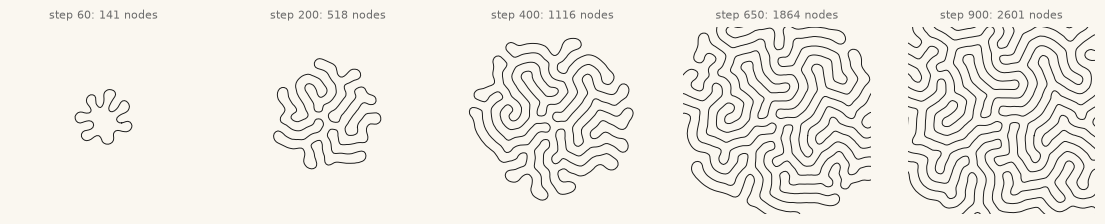

In [5]:
# the filmstrip: one organism, five ages
ages = list(shots.items()) + [(900, final)]
fig, axes = plt.subplots(1, 5, figsize=(14, 3.2), facecolor=PAPER)
for ax, (age, loop) in zip(axes, ages):
    closed = np.vstack([loop, loop[:1]])
    ax.plot(closed[:, 0], closed[:, 1], color="#1A1A1A", lw=0.7)
    ax.set_xlim(-95, 95)
    ax.set_ylim(-95, 95)
    ax.set_aspect("equal")
    ax.set_title(f"step {age}: {len(loop)} nodes", fontsize=8, color="#6B6B6B")
    ax.axis("off")
plt.show()

**Look and compare.** The frill erupts. For its first hundred steps the loop is a slightly nervous circle; then a few waves find each other, the waves sprout waves, and by step 650 the organism is a meandering coastline that no longer remembers being round. The filmstrip is chapter 14's trick for watching a process instead of a result, and the resemblance to that chapter's chemistry is not a coincidence we will let pass unremarked (it gets its sentence at the labyrinth below).

The inevitability argument made one measurable promise: perimeter should multiply. Let us check it, on the logarithmic axis where steady multiplication shows as a straight climb (chapter 9's instrument).

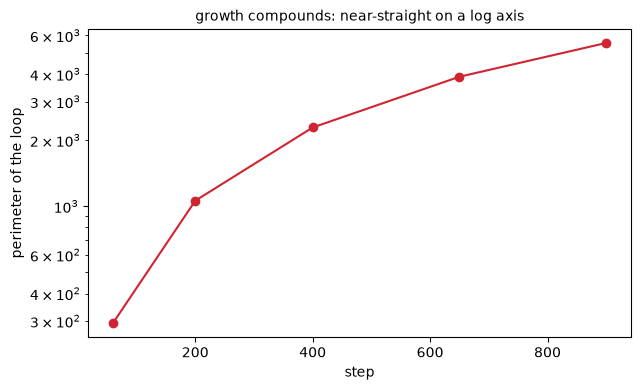

In [6]:
# the promise, audited: perimeter over time, on a log axis
lengths_by_age = []
for age, loop in ages:
    edges = np.roll(loop, -1, axis=0) - loop
    lengths_by_age.append(np.hypot(edges[:, 0], edges[:, 1]).sum())

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy([a for a, _ in ages], lengths_by_age, "o-", color="#D02433")
ax.set_xlabel("step")
ax.set_ylabel("perimeter of the loop")
ax.set_title("growth compounds: near-straight on a log axis", fontsize=10)
plt.show()

## Two dials, three species

Everything the organism *is* lives in the balance between how fast it grows (`sprout_rate`) and how far its skin senses strangers (`repel_radius`). Three presets, honestly labeled, the third one a failure kept on purpose.

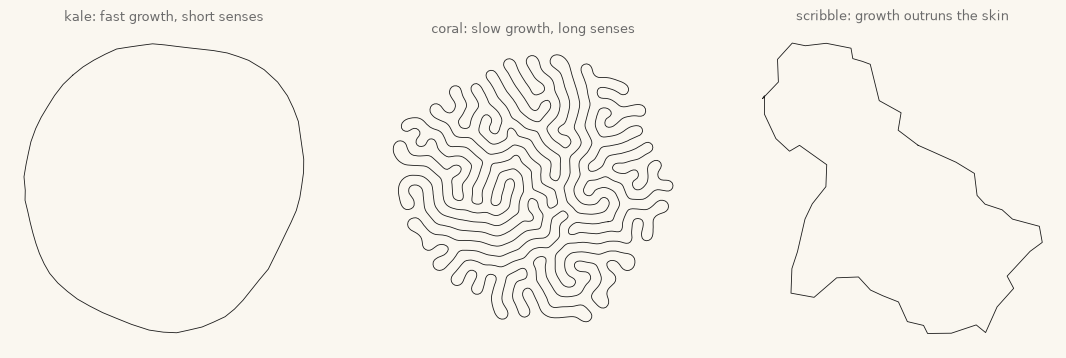

In [7]:
# kale, coral, scribble: the personality space of two dials
species = [
    ("kale: fast growth, short senses", dict(sprout_rate=3.0, repel_radius=6.0,
                                             edge_max=2.0, max_nodes=2600)),
    ("coral: slow growth, long senses", dict(sprout_rate=0.35, repel_radius=16.0,
                                             edge_max=3.4, max_nodes=2600)),
    ("scribble: growth outruns the skin", dict(sprout_rate=9.0, repel_radius=3.0,
                                               edge_max=1.6, jitter=0.3,
                                               max_nodes=2600)),
]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), facecolor=PAPER)
for ax, (label, kwargs) in zip(axes, species):
    loop, _ = grow(steps=900, seed=5, **kwargs)
    closed = np.vstack([loop, loop[:1]])
    ax.plot(closed[:, 0], closed[:, 1], color="#1A1A1A", lw=0.6)
    ax.set_aspect("equal")
    ax.set_title(label, fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

**Look and compare.** Kale's short-sighted, fast-growing line packs tight, even ruffles: the hem of the leaf. Coral, growing slowly with long-range repulsion, holds wide, smooth lobes apart like fan coral in a current. And the scribble is what failure looks like in this system, shown because you will meet it the moment you explore on your own: grow faster than repulsion can organize (here with the tremble turned up as well) and the line crumples into overlapping chaos, no longer a drawing of anything. The lesson generalizes across Part V: every agent system has a regime where its negotiation machinery keeps up, and a cliff where it does not.

**Try it.** `seed=5` grew all three; change it and the species keep their characters while every individual differs: genotype in the dials, biography in the seed (chapter 2's oldest lesson, still true at four thousand nodes).

## The packed labyrinth

One more ingredient and we reach the showpiece: a wall. Chapter 19 cushioned its flock inside a box with a soft push; the same idiom, aimed inward from a circle, pens the growing line into a fixed arena. Growth does not stop at the wall, it *accumulates* against it, and the frill, denied outward escape, folds inward until it has paved the disk.

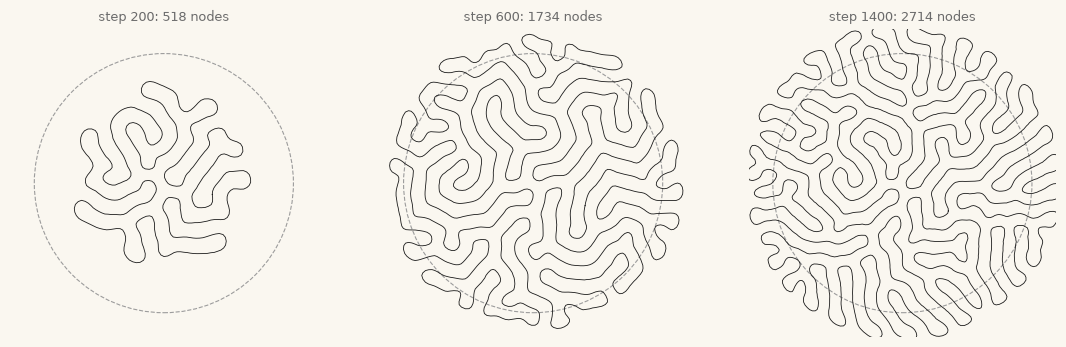

In [8]:
# growth under confinement: the line paves its cage
caged, cage_shots = grow(steps=1400, boundary=80, max_nodes=3600,
                         snapshots=(200, 600), seed=1)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), facecolor=PAPER)
stages = list(cage_shots.items()) + [(1400, caged)]
wall = plt.Circle((0, 0), 80, fill=False, color="#9C9C9C", lw=0.8, ls="--")
for ax, (age, loop) in zip(axes, stages):
    closed = np.vstack([loop, loop[:1]])
    ax.add_patch(plt.Circle((0, 0), 80, fill=False, color="#9C9C9C",
                            lw=0.8, ls="--"))
    ax.plot(closed[:, 0], closed[:, 1], color="#1A1A1A", lw=0.6)
    ax.set_xlim(-95, 95)
    ax.set_ylim(-95, 95)
    ax.set_aspect("equal")
    ax.set_title(f"step {age}: {len(loop)} nodes", fontsize=9, color="#6B6B6B")
    ax.axis("off")
plt.show()

**Look and compare** the right panel with chapter 14's showpiece, the reaction-diffusion labyrinth. Two systems with nothing in common mechanically, one a field of simulated chemistry, the other a single elastic line, arrive at the *same look*: meandering lanes at a uniform spacing, filling a region wall to wall. That convergence is the punchline Parts III to V have been building: labyrinths appear wherever something grows or reacts under two constraints, *fill the space* and *keep your distance*, and the universe does not much care whether chemistry, geometry, or a flock of birds does the negotiating. When two of your systems agree this well, you have not repeated yourself; you have found a law.

## Export your artwork

Grow your own: choose a species preset (or your own dials), a wall radius or open water, a seed, and ink it. The single-line constraint rewards restraint: one color, thin pen, paper ground.

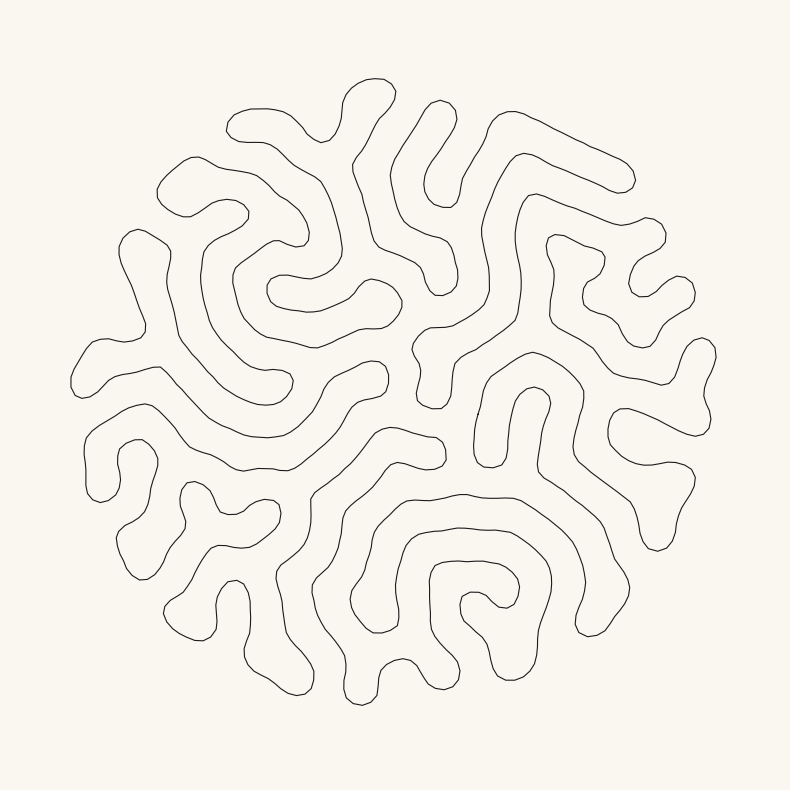

saved: assets/outputs/ch22_yourname.png


In [9]:
# save YOUR organism: tune dials, replace 'yourname', run
my_loop, _ = grow(steps=1100, boundary=70, max_nodes=3000,
                  sprout_rate=2.2, repel_radius=8.0, seed=24)
my_artwork, my_ax = plt.subplots(figsize=(10, 10), facecolor=PAPER)
my_closed = np.vstack([my_loop, my_loop[:1]])
my_ax.plot(my_closed[:, 0], my_closed[:, 1], color="#1A1A1A", lw=0.8)
my_ax.set_xlim(-88, 88)
my_ax.set_ylim(-88, 88)
my_ax.set_aspect("equal")
my_ax.axis("off")
plt.show()
saved_path = save_artwork(my_artwork, "yourname", chapter=22)

## Exercises

**(a) Parameter exploration: the kale-coral-scribble axis.** Render a 3 by 3 grid crossing `sprout_rate` $\in \{0.4, 1.5, 6.0\}$ with `repel_radius` $\in \{4, 10, 18\}$ (steps around 600 and `max_nodes=1500` keep the grid quick). One sentence per cell: name each regime's character, and mark where the scribble cliff runs through the grid.

**(b) Code modification: the hanging frill.** Growth on an *open* curve: a horizontal line of nodes whose two endpoints are pinned like the corners of a clothesline, everything between free to grow and sag. Copy `grow` into `grow_open` with three changes: build the starting positions as a line instead of a circle; replace the rolled (wrap-around) neighbor arithmetic for cohesion, edges and the stranger test with their open-chain versions; and after each step, snap the two endpoints back to their pinned positions. Grow it and watch a curtain frill fall out of the line.

<details><summary>Solution</summary>

```python
def grow_open(steps=800, n_start=30, width=120, max_nodes=2200,
              cohesion=0.22, repulsion=0.55, repel_radius=8.0,
              edge_max=2.4, edge_min=0.9, jitter=0.05, sprout_rate=1.2,
              seed=2):
    rng = np.random.default_rng(seed)
    xs = np.linspace(-width / 2, width / 2, n_start)
    pos = np.column_stack([xs, np.zeros(n_start)])
    pin_left, pin_right = pos[0].copy(), pos[-1].copy()
    for step in range(steps):
        n = len(pos)
        force = np.zeros_like(pos)
        force[1:-1] = cohesion * (pos[:-2] + pos[2:] - 2 * pos[1:-1])
        tree = cKDTree(pos)                    # rebuilt every step: simpler
        pairs = tree.query_pairs(repel_radius, output_type="ndarray")
        if len(pairs):
            i, j = pairs[:, 0], pairs[:, 1]
            strangers = np.abs(i - j) > 2      # no wrap-around on an open chain
            i, j = i[strangers], j[strangers]
            if len(i):
                offsets = pos[i] - pos[j]
                dist = np.hypot(offsets[:, 0], offsets[:, 1]) + 1e-9
                push = ((1 - dist / repel_radius)[:, None]
                        * offsets / dist[:, None]) * repulsion
                np.add.at(force, i, push)
                np.add.at(force, j, -push)
        force += rng.normal(0, jitter, pos.shape)
        force[:, 1] -= 0.01                    # a little gravity: it is laundry
        pos = pos + force
        pos[0], pos[-1] = pin_left, pin_right  # the pins
        if len(pos) < max_nodes:
            edges = pos[1:] - pos[:-1]         # open chain: n-1 edges, no roll
            lengths = np.hypot(edges[:, 0], edges[:, 1])
            split = np.nonzero(lengths > edge_max)[0]
            sprouts = rng.poisson(sprout_rate)
            if sprouts:
                split = np.union1d(split, rng.integers(0, len(pos) - 1, sprouts))
            if len(split):
                midpoints = (pos[split] + pos[split + 1]) / 2
                pos = np.insert(pos, split + 1, midpoints, axis=0)
        edges = pos[1:] - pos[:-1]
        lengths = np.hypot(edges[:, 0], edges[:, 1])
        keep = np.concatenate([[True], lengths > edge_min])
        keep[-1] = True                        # never drop the pinned ends
        if keep.sum() > 10 and not keep.all():
            pos = pos[keep]
    return pos

curtain = grow_open()
fig, ax = plt.subplots(figsize=(10, 6), facecolor=PAPER)
ax.plot(curtain[:, 0], curtain[:, 1], color="#1A1A1A", lw=0.7)
ax.plot([curtain[0, 0], curtain[-1, 0]], [curtain[0, 1], curtain[-1, 1]],
        "o", color="#D02433", markersize=5)
ax.set_aspect("equal")
ax.axis("off")
plt.show()
```

The middle grows, the ends cannot, and the surplus length sags and ruffles downward into a hanging frill (the pinch of gravity makes it drape instead of exploding evenly). This is the kale hem in its purest form: growth between fixed boundaries, with the buckling pushed to where the growing is.
</details>

**(c) Creative challenge: grow from a silhouette.** The starting loop need not be a circle. Seed it from a shape you care about: a large letterform (render text to pixels, threshold it, and walk the outline), or an outline sampled with chapter 15's machinery, and let the growth erupt from *that*, gently (low `sprout_rate`, a few hundred steps), so the original shape remains legible under the frill, a word becoming a reef. Or take today's finished labyrinth to chapter 26's plotter discipline: sort nothing, optimize nothing, the artwork is already one continuous line, the plotter's dream, and draw it in a single unbroken stroke of real ink.

## Further reading

- D'Arcy Wentworth Thompson, *On Growth and Form* (1917; expanded edition 1942): the ancestral text for everything in this chapter, and still a pleasure to read on its own terms.
- Eran Sharon, Benoît Roman, Michael Marder, Gyu-Seung Shin and Harry L. Swinney, "Buckling cascades in free sheets", *Nature* 419 (2002): the torn-plastic experiment showing that a fast-growing edge buckles into waves upon waves, no blueprint required.
- Tuomas Tallinen and colleagues, "On the growth and form of cortical convolutions", *Nature Physics* 12 (2016): differential growth folding a gel-brain, with the title's bow to Thompson.
- Anders Hoff's essay series on generative algorithms at inconvergent.net, especially "Differential Line": the canonical creative-coding treatment this chapter's engine descends from.
- Nervous System's project pages and blog at n-e-r-v-o-u-s.com document *Hyphae* and *Floraform*, where these simulations become objects you can wear.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image at the top of the notebook: one closed line grown for 1600 steps to about 3600 nodes inside a soft circular wall, ink on paper, fixed seed. About 15 seconds; it runs automatically with *Restart & Run All*.

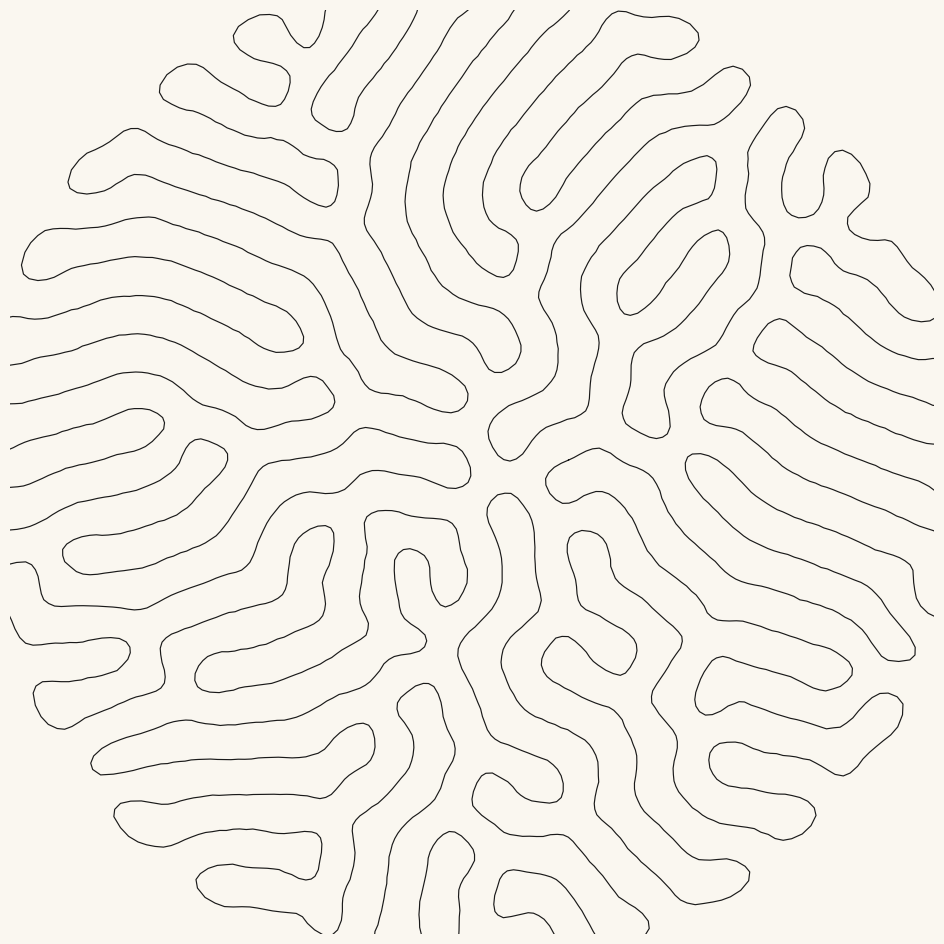

3060 nodes, one unbroken line
saved: assets/outputs/ch22_showpiece.png


In [10]:
# regenerate this chapter's showpiece: the packed labyrinth, one line of ink
sp_loop, _ = grow(steps=1600, boundary=80, max_nodes=3600,
                  sprout_rate=1.5, repel_radius=10.0, seed=7)
showpiece, sp_ax = plt.subplots(figsize=(12, 12), facecolor=PAPER)
sp_closed = np.vstack([sp_loop, sp_loop[:1]])
sp_ax.plot(sp_closed[:, 0], sp_closed[:, 1], color="#1A1A1A", lw=0.85)
sp_ax.set_xlim(-92, 92)
sp_ax.set_ylim(-92, 92)
sp_ax.set_aspect("equal")
sp_ax.axis("off")
plt.show()
print(f"{len(sp_loop)} nodes, one unbroken line")
saved_path = save_artwork(showpiece, "showpiece", chapter=22)